## MindBigData VisualMNIST 2023 — 128-channel EEG

Dataset: `DavidVivancos/MindBigData2023_MNIST-8B` ([HuggingFace](https://huggingface.co/datasets/DavidVivancos/MindBigData2023_MNIST-8B)) · [Paper](https://arxiv.org/abs/2306.00455)

**Single subject** recorded with a custom 128-channel EEG cap at **250 Hz**.
Stimulus: subject watched MNIST digit pixels on screen while simultaneously listening to the spoken digit (0–9).
Each epoch is **2 seconds** (500 samples @ 250 Hz). Raw signals are ADC counts (÷1000 → µV).

**Schema (64,791 columns):**
- `<CHANNEL>_0` … `<CHANNEL>_499`: 128 EEG channels × 500 samples = 64,000 columns
- `label`: digit 0–9, or -1 (black-screen / no stimulus)
- `label_source`, `label_pos`: label metadata
- `label_imgpix_0` … `label_imgpix_783`: flattened 28×28 MNIST image (784 columns)
- `timestamp`, `sessionnum`, `blocknum`, `blockpos`: recording metadata

**Sizes:** 120,000 train rows (70k digit + 50k black-screen) · 20,000 test rows (10k digit + 10k black-screen)

**Output structure used in this notebook:**
- `all_data["meta"]`: pandas DataFrame
- `all_data["images"]`: NumPy array `(n, 28, 28)`
- `all_data["eeg"]`: NumPy array `(n, 128, 500)`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_rel = Path("data/raw")
raw_candidates = [raw_rel, Path("../../") / raw_rel]
raw_dir = next((p for p in raw_candidates if p.exists()), raw_rel)
if not raw_dir.exists():
    raise FileNotFoundError(f"Raw data dir not found. Tried: {raw_candidates}")

TRAIN_PATH = raw_dir / "train.csv"
TEST_PATH  = raw_dir / "test.csv"
COORDS_PATH = raw_dir / "3Dcoords.csv"

N_CHANNELS = 128
N_SAMPLES  = 500
IMG_PIXELS = 784

META_COLS = ["label", "label_source", "label_pos", "timestamp", "sessionnum", "blocknum", "blockpos"]
IMG_COLS  = [f"label_imgpix_{i}" for i in range(IMG_PIXELS)]

print(f"Train: {TRAIN_PATH}  exists={TRAIN_PATH.exists()}")
print(f"Test:  {TEST_PATH}   exists={TEST_PATH.exists()}")
print(f"Coords:{COORDS_PATH} exists={COORDS_PATH.exists()}")

Train: ../../data/raw/train.csv  exists=True
Test:  ../../data/raw/test.csv   exists=True
Coords:../../data/raw/3Dcoords.csv exists=True


In [2]:
# Quick schema sanity check on a tiny sample
head_df = pd.read_csv(TRAIN_PATH, nrows=3)
print("Tiny sample shape:", head_df.shape)

expected_cols = len(META_COLS) + IMG_PIXELS + N_CHANNELS * N_SAMPLES  # 7 + 784 + 64000 = 64791
print(f"Total columns: {head_df.shape[1]}  (expected {expected_cols})")
print("Expected EEG columns:", N_CHANNELS * N_SAMPLES)

if head_df.shape[1] != expected_cols:
    print(f"WARNING: column count mismatch! got {head_df.shape[1]}, expected {expected_cols}")

# Identify EEG column blocks
all_cols = list(head_df.columns)
eeg_cols = [c for c in all_cols if "_" in c and c.split("_")[-1].isdigit() and c not in IMG_COLS]
img_cols_found = [c for c in all_cols if c in IMG_COLS]
meta_cols_found = [c for c in all_cols if c in META_COLS]

print(f"\nMeta cols found ({len(meta_cols_found)}): {meta_cols_found}")
print(f"Image cols found: {len(img_cols_found)}")
print(f"EEG cols found: {len(eeg_cols)}")

# Derive channel names from EEG columns
channel_names = list(dict.fromkeys(c.rsplit("_", 1)[0] for c in eeg_cols))
print(f"\nChannels ({len(channel_names)}): {channel_names[:10]} ...")

# Show combined raw schema index summary
eeg_idx = [head_df.columns.get_loc(c) for c in eeg_cols]
img_idx = [head_df.columns.get_loc(c) for c in img_cols_found]

print("\n--- Raw-data schema index summary ---")
print("(0-based column positions in raw CSV)")
print(f"EEG data columns:   {min(eeg_idx)} to {max(eeg_idx)}  (count={len(eeg_idx)})")
print(f"Image data columns: {min(img_idx)} to {max(img_idx)}  (count={len(img_idx)})")
print("Meta columns (raw index -> name):")
for col in meta_cols_found:
    print(f"  {head_df.columns.get_loc(col)}: {col}")
print("Schema order: [EEG block] -> [label/label_source/label_pos] -> [image block] -> [timestamp/session/block]")

print("\n--- Meta data preview (first row) ---")
print(head_df[meta_cols_found].iloc[0])

Tiny sample shape: (3, 64791)
Total columns: 64791  (expected 64791)
Expected EEG columns: 64000

Meta cols found (7): ['label', 'label_source', 'label_pos', 'timestamp', 'sessionnum', 'blocknum', 'blockpos']
Image cols found: 784
EEG cols found: 64000

Channels (128): ['FP1', 'FPz', 'FP2', 'AFp1', 'AFPz', 'AFp2', 'AF7', 'AF3', 'AF4', 'AF8'] ...

--- Raw-data schema index summary ---
(0-based column positions in raw CSV)
EEG data columns:   0 to 63999  (count=64000)
Image data columns: 64003 to 64786  (count=784)
Meta columns (raw index -> name):
  64000: label
  64001: label_source
  64002: label_pos
  64787: timestamp
  64788: sessionnum
  64789: blocknum
  64790: blockpos
Schema order: [EEG block] -> [label/label_source/label_pos] -> [image block] -> [timestamp/session/block]

--- Meta data preview (first row) ---
label                       -1
label_source             TRAIN
label_pos                    0
timestamp       1674554158.426
sessionnum                   0
blocknum        

In [3]:
def parse_cap128_chunk(chunk, eeg_cols, img_cols, channel_names):
    """Convert one raw CSV chunk into typed meta DataFrame + image/eeg arrays.

    Use this inside chunked reading loops.
    Input:
      - chunk: DataFrame from pd.read_csv(..., chunksize=...)
      - eeg_cols/img_cols: column name lists selected from schema
      - channel_names: ordered EEG channel names (len = EEG channel count)
    Returns:
      - meta: DataFrame with cleaned metadata columns
      - images: float32 array shaped (n_rows, 28, 28)
      - eeg: float32 array shaped (n_rows, n_channels, 500)
    """
    meta = pd.DataFrame({
        "label":      pd.to_numeric(chunk["label"], errors="coerce").round().astype("Int64"),
        "label_source": chunk["label_source"].astype("string") if "label_source" in chunk else pd.NA,
        "label_pos":  pd.to_numeric(chunk.get("label_pos"), errors="coerce").astype("Int64") if "label_pos" in chunk else pd.NA,
        "timestamp":  pd.to_numeric(chunk["timestamp"], errors="coerce"),
        "sessionnum": pd.to_numeric(chunk["sessionnum"], errors="coerce").astype("Int64"),
        "blocknum":   pd.to_numeric(chunk["blocknum"], errors="coerce").astype("Int64"),
        "blockpos":   pd.to_numeric(chunk["blockpos"], errors="coerce").astype("Int64"),
    })

    images = chunk[img_cols].to_numpy(dtype=np.float32).reshape(-1, 28, 28)
    eeg    = chunk[eeg_cols].to_numpy(dtype=np.float32).reshape(-1, len(channel_names), 500)
    return meta, images, eeg


def load_cap128(path, eeg_cols, img_cols, channel_names, chunksize=256, max_rows=None):
    """Load full CSV in chunks and combine into one dictionary.

    Typical use:
      all_data = load_cap128(TRAIN_PATH, eeg_cols, img_cols_found, channel_names,
                             chunksize=256, max_rows=5000)

    Returns:
      {"meta": DataFrame, "images": ndarray, "eeg": ndarray}
    """
    meta_parts, img_parts, eeg_parts = [], [], []
    loaded_rows = 0

    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        if max_rows is not None and loaded_rows >= max_rows:
            break
        if max_rows is not None and loaded_rows + len(chunk) > max_rows:
            chunk = chunk.iloc[: max_rows - loaded_rows]

        m, i, e = parse_cap128_chunk(chunk, eeg_cols, img_cols, channel_names)
        meta_parts.append(m)
        img_parts.append(i)
        eeg_parts.append(e)
        loaded_rows += len(chunk)
        if loaded_rows % 5000 == 0:
            print(f"  loaded {loaded_rows} rows...")

    meta   = pd.concat(meta_parts, ignore_index=True)
    images = np.concatenate(img_parts, axis=0)
    eeg    = np.concatenate(eeg_parts, axis=0)
    return {"meta": meta, "images": images, "eeg": eeg}

## Load Train Dataset

120,000 rows × 64,791 columns — this is a large file. Loaded in chunks to control memory.

`label = -1` is a black-screen event (no digit shown).

Set `MAX_ROWS = None` to load the full dataset.

In [4]:
MAX_ROWS = 500  # set to None to load the full 120k rows

print(f"Loading train set (max_rows={MAX_ROWS})...")
all_data = load_cap128(TRAIN_PATH, eeg_cols, img_cols_found, channel_names, chunksize=256, max_rows=MAX_ROWS)

print("\nmeta:",   all_data["meta"].shape)
print("images:", all_data["images"].shape)
print("eeg:",    all_data["eeg"].shape)

label_counts = all_data["meta"]["label"].value_counts(dropna=False).sort_index()
print("\nLabel distribution:")
display(label_counts)

digit_mask = all_data["meta"]["label"].between(0, 9)
print("\nDigit rows (0-9):", int(digit_mask.sum()))
print("Black-screen rows (-1):", int((all_data["meta"]["label"] == -1).sum()))

Loading train set (max_rows=500)...

meta: (500, 7)
images: (500, 28, 28)
eeg: (500, 128, 500)

Label distribution:


label
-1    250
0      30
1      34
2      23
3      27
4      24
5      17
6      24
7      26
8      19
9      26
Name: count, dtype: Int64


Digit rows (0-9): 250
Black-screen rows (-1): 250


In [5]:
# Digits-only filtered view
meta   = all_data["meta"]
images = all_data["images"]
eeg    = all_data["eeg"]

is_digit = meta["label"].between(0, 9).to_numpy()

data_digits = {
    "meta":   meta[is_digit].reset_index(drop=True),
    "images": images[is_digit],
    "eeg":    eeg[is_digit],
}

print("Digits-only shapes:")
print("meta:",   data_digits["meta"].shape)
print("images:", data_digits["images"].shape)
print("eeg:",    data_digits["eeg"].shape)

data_digits["meta"].head()

Digits-only shapes:
meta: (250, 7)
images: (250, 28, 28)
eeg: (250, 128, 500)


,label,label_source,label_pos,timestamp,sessionnum,blocknum,blockpos
0,5,TRAIN,0,1.674554e+09,0,0,1
1,0,TRAIN,1,1.674554e+09,0,0,3
2,4,TRAIN,2,1.674554e+09,0,0,5
3,1,TRAIN,3,1.674554e+09,0,0,7
4,9,TRAIN,4,1.674554e+09,0,0,9


In [64]:
# Scale EEG to µV
# Raw values are ADC counts; dividing by 1000 converts to µV (±80 µV range, std ~14 µV)

EEG_SCALE = 1000.0  # ADC counts → µV
SFREQ  = 250.0      # Hz (confirmed sampling rate)

eeg_uv        = eeg / EEG_SCALE
digits_eeg_uv = data_digits["eeg"] / EEG_SCALE

print(f"After scaling (÷{EEG_SCALE:.0f}):")
print(f"  EEG range: min={eeg_uv.min():.2f}  max={eeg_uv.max():.2f}  std={eeg_uv.std():.2f} µV")

After scaling (÷1000):
  EEG range: min=-515.07  max=509.18  std=12.47 µV


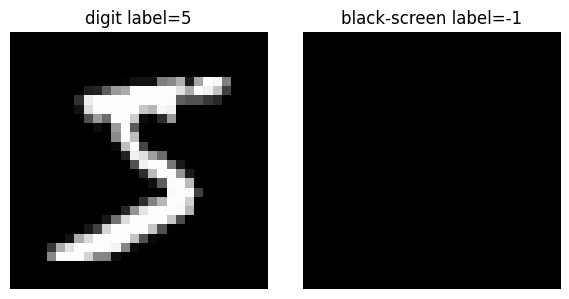

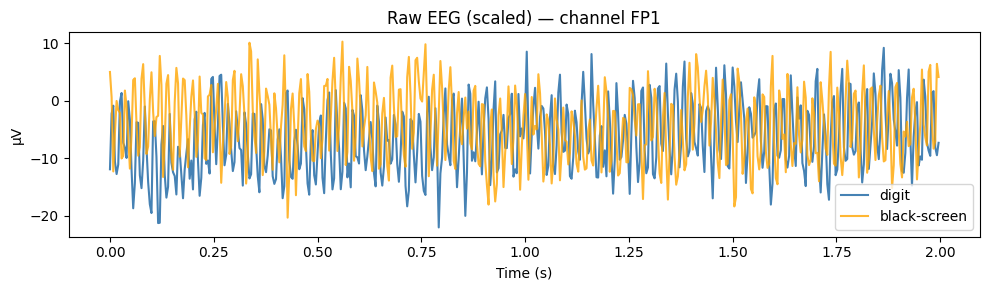

In [65]:
# Visualize one digit sample vs one black-screen sample (scaled µV)
real_idx  = meta.index[meta["label"].between(0, 9)][0]
black_idx = meta.index[meta["label"] == -1][0]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(images[real_idx], cmap="gray")
axes[0].set_title(f"digit label={meta.iloc[real_idx]['label']}")
axes[0].axis("off")
axes[1].imshow(images[black_idx], cmap="gray")
axes[1].set_title("black-screen label=-1")
axes[1].axis("off")
plt.tight_layout()
plt.show()

time_axis = np.arange(N_SAMPLES) / SFREQ  # seconds

ch = 0
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_axis, eeg_uv[real_idx, ch],  label="digit",        color="steelblue")
ax.plot(time_axis, eeg_uv[black_idx, ch], label="black-screen", color="orange", alpha=0.8)
ax.set_title(f"Raw EEG (scaled) — channel {channel_names[ch]}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("µV")
ax.legend()

plt.tight_layout()
plt.show()

In [66]:
# Timestamp audit
meta_time = meta.copy()
median_ts = meta_time["timestamp"].median()
ts_unit = "ms" if median_ts > 1e12 else "s"

meta_time["recorded_at"] = pd.to_datetime(meta_time["timestamp"], unit=ts_unit, errors="coerce", utc=True)
meta_time["recorded_date"] = meta_time["recorded_at"].dt.date

print("Timestamp unit inferred:", ts_unit)
print("First recording:", meta_time["recorded_at"].min())
print("Last recording:",  meta_time["recorded_at"].max())
print("Unique dates:", meta_time["recorded_date"].nunique())

date_counts = meta_time["recorded_date"].value_counts(dropna=False).sort_index()
print("\nSamples per recording date:")
display(date_counts)

Timestamp unit inferred: s
First recording: 2023-01-24 09:55:58.426000118+00:00
Last recording: 2023-01-24 10:50:02.285000086+00:00
Unique dates: 1

Samples per recording date:


recorded_date
2023-01-24    500
Name: count, dtype: int64

In [67]:
# Session / block structure
print("Unique sessions:", meta["sessionnum"].nunique())
print("Unique blocks:",   meta["blocknum"].nunique())

sess_counts = meta["sessionnum"].value_counts().sort_index()
print("\nSamples per session (top 20):")
display(sess_counts.head(20))

label_by_session = meta.groupby("sessionnum")["label"].value_counts(dropna=False).unstack(fill_value=0)
print("\nLabel distribution per session (first 5 sessions):")
display(label_by_session.head())

Unique sessions: 1
Unique blocks: 50

Samples per session (top 20):


sessionnum
0    500
Name: count, dtype: Int64


Label distribution per session (first 5 sessions):


label,-1,0,1,2,3,4,5,6,7,8,9
sessionnum,,,,,,,,,,,
0,250,30,34,23,27,24,17,24,26,19,26


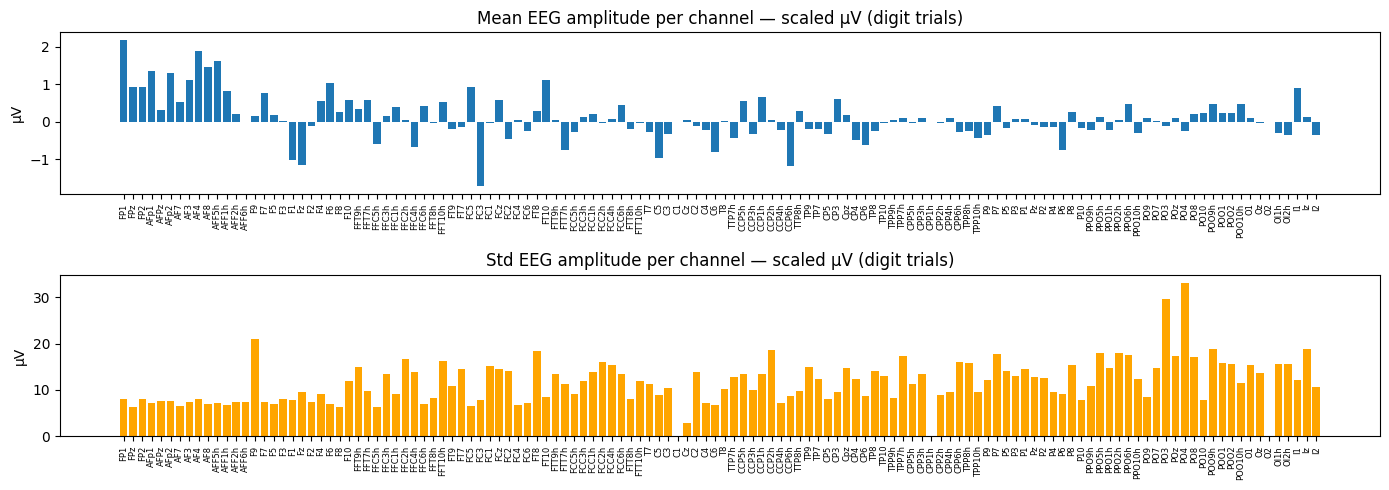

In [68]:
# EEG signal statistics (scaled µV)
eeg_d = digits_eeg_uv  # (n, 128, 500)

ch_means = eeg_d.mean(axis=(0, 2))
ch_stds  = eeg_d.std(axis=(0, 2))

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].bar(range(len(channel_names)), ch_means)
axes[0].set_title("Mean EEG amplitude per channel — scaled µV (digit trials)")
axes[0].set_ylabel("µV")
axes[0].set_xticks(range(len(channel_names)))
axes[0].set_xticklabels(channel_names, rotation=90, fontsize=6)

axes[1].bar(range(len(channel_names)), ch_stds, color="orange")
axes[1].set_title("Std EEG amplitude per channel — scaled µV (digit trials)")
axes[1].set_ylabel("µV")
axes[1].set_xticks(range(len(channel_names)))
axes[1].set_xticklabels(channel_names, rotation=90, fontsize=6)

plt.tight_layout()
plt.show()

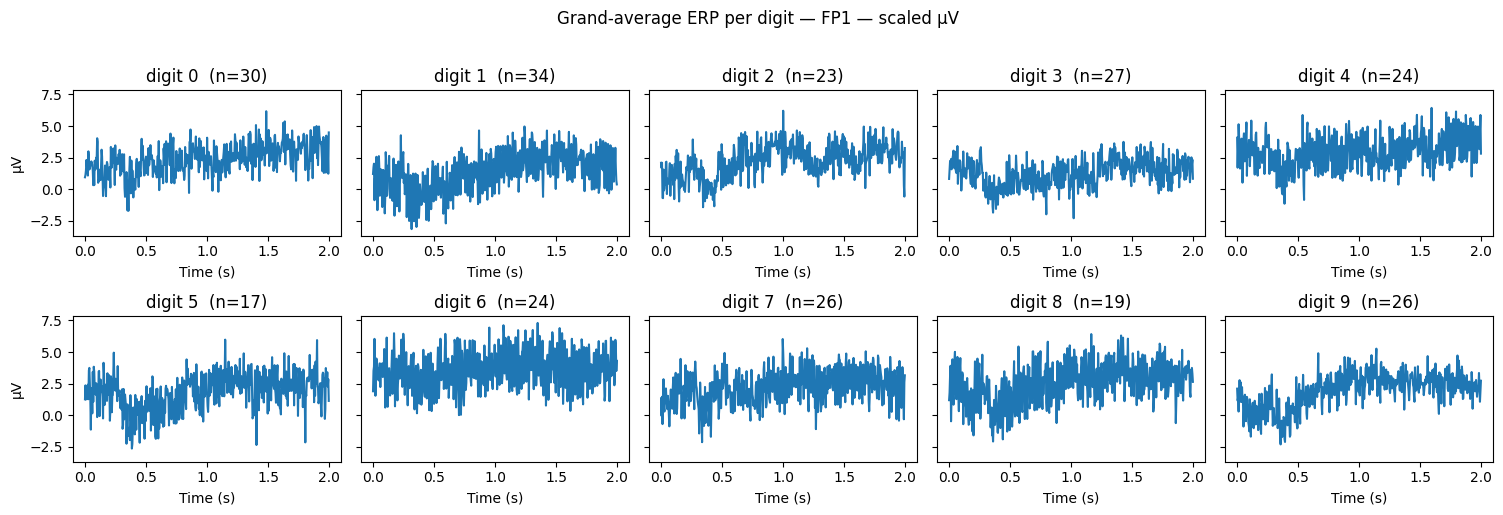

In [69]:
# Grand average ERP per digit (channel 0)
time_axis = np.arange(N_SAMPLES) / SFREQ  # seconds

ch = 0
fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharey=True)
for digit, ax in enumerate(axes.flat):
    mask = data_digits["meta"]["label"] == digit
    erp = digits_eeg_uv[mask.to_numpy(), ch, :].mean(axis=0)
    ax.plot(time_axis, erp)
    ax.set_title(f"digit {digit}  (n={int(mask.sum())})")
    ax.set_xlabel("Time (s)")
    if digit % 5 == 0:
        ax.set_ylabel("µV")
plt.suptitle(f"Grand-average ERP per digit — {channel_names[ch]} — scaled µV", y=1.02)
plt.tight_layout()
plt.show()

3Dcoords shape: (130, 4)


,channel,x,y,z
0,FP1,-0.089225,0.162751,0.206887
1,FPz,-0.025989,0.158658,0.222525
2,FP2,0.050176,0.159814,0.210255
3,AFp1,-0.063429,0.131821,0.241846
4,AFPz,-0.032623,0.091798,0.272591
5,AFp2,0.004771,0.129760,0.244177
6,AF7,-0.153275,0.132822,0.163885
7,AF3,-0.118963,0.099781,0.239831
8,AF4,0.061932,0.095614,0.251248
9,AF8,0.109812,0.132773,0.184186


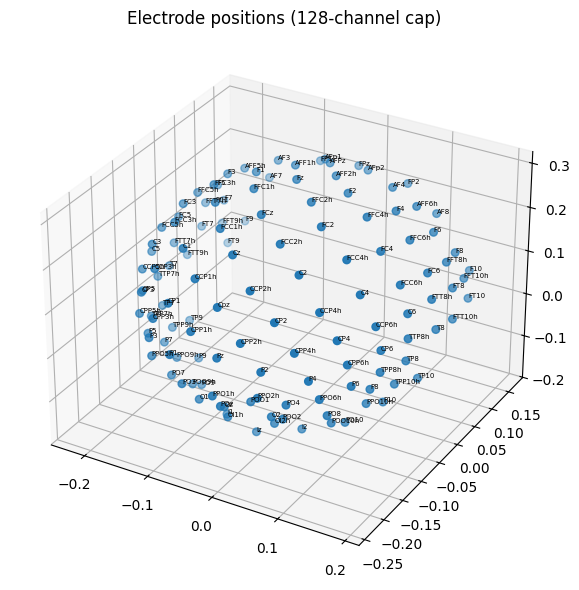

In [70]:
# 3D electrode coordinates
coords = pd.read_csv(COORDS_PATH)
print("3Dcoords shape:", coords.shape)
display(coords.head(10))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(coords["x"], coords["y"], coords["z"], s=30)
for _, row in coords.iterrows():
    ax.text(row["x"], row["y"], row["z"], row["channel"], fontsize=5)
ax.set_title("Electrode positions (128-channel cap)")
plt.tight_layout()
plt.show()

In [71]:
# Summary
print("=== Dataset Summary ===")
print(f"Single subject · custom 128-channel EEG cap")
print(f"Sampling rate: {SFREQ:.0f} Hz · Epoch: {N_SAMPLES / SFREQ:.1f} s ({N_SAMPLES} samples)")
print(f"Signal scaling: ÷{EEG_SCALE:.0f} (ADC → µV)")
print()
print(f"Train samples loaded: {len(meta)}  (max_rows={MAX_ROWS})")
print(f"  Digit (0-9):       {int(digit_mask.sum())}")
print(f"  Black-screen (-1): {int((meta['label'] == -1).sum())}")
print(f"EEG shape: {eeg.shape}  →  scaled: {eeg_uv.shape}")
print(f"Image shape: {images.shape}")
print(f"Sessions: {meta['sessionnum'].nunique()}")
print(f"Blocks:   {meta['blocknum'].nunique()}")
print(f"Recording span: {meta_time['recorded_at'].min()} → {meta_time['recorded_at'].max()}")

=== Dataset Summary ===
Single subject · custom 128-channel EEG cap
Sampling rate: 250 Hz · Epoch: 2.0 s (500 samples)
Signal scaling: ÷1000 (ADC → µV)

Train samples loaded: 500  (max_rows=500)
  Digit (0-9):       250
  Black-screen (-1): 250
EEG shape: (500, 128, 500)  →  scaled: (500, 128, 500)
Image shape: (500, 28, 28)
Sessions: 1
Blocks:   50
Recording span: 2023-01-24 09:55:58.426000118+00:00 → 2023-01-24 10:50:02.285000086+00:00
